In [4]:
!pip install lime scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 14.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=c640c256b2f006d48e9c054fbf04b8b5f76e496986c97893170e7c878aca9431
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from lime import lime_image
from skimage.segmentation import mark_boundaries

transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = ['airplane', 'automobile', 'bird', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.fc1 = nn.Linear(32 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Training Started...\n")

for epoch in range(10):
    running_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.3f}")

print("\nTraining Completed")

def predict(images):
    images = torch.tensor(images).permute(0, 3, 1, 2).float()
    outputs = model(images)
    probs = torch.softmax(outputs, dim=1)
    return probs.detach().numpy()

dataiter = iter(testloader)
images, labels = next(dataiter)

image = images[0].permute(1, 2, 0).numpy()
label = labels[0].item()

plt.imshow(image)
plt.title(f"Actual Label: {classes[label]}")
plt.axis('off')
plt.show()

explainer = lime_image.LimeImageExplainer()

print("Generating LIME Explanation...")

explanation = explainer.explain_instance(
    image,
    predict,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.title("LIME Explanation (Important Regions Highlighted)")
plt.axis('off')
plt.show()

Training Started...

Epoch 1, Loss: 522.092
Epoch 2, Loss: 340.156
Epoch 3, Loss: 296.709
Epoch 4, Loss: 268.790
Epoch 5, Loss: 250.906
Epoch 6, Loss: 235.064
Epoch 7, Loss: 220.537
Epoch 8, Loss: 206.963
Epoch 9, Loss: 193.704
Epoch 10, Loss: 183.879
Epoch 11, Loss: 174.053
Epoch 12, Loss: 165.896
Epoch 13, Loss: 155.906
Epoch 14, Loss: 147.243
Epoch 15, Loss: 139.016
Epoch 16, Loss: 132.830
Epoch 17, Loss: 123.212
Epoch 18, Loss: 119.116
Epoch 19, Loss: 111.328
Epoch 20, Loss: 104.600
Epoch 21, Loss: 98.378
Epoch 22, Loss: 91.755
Epoch 23, Loss: 86.624
Epoch 24, Loss: 81.013
Epoch 25, Loss: 76.847

Training Completed


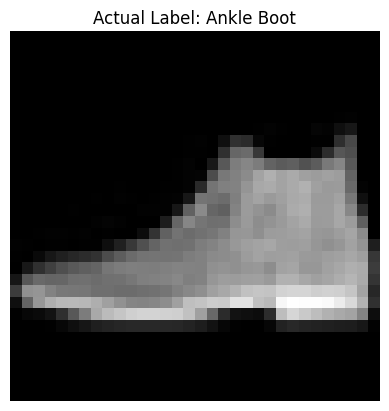

Generating LIME Explanation...


  0%|          | 0/1000 [00:00<?, ?it/s]

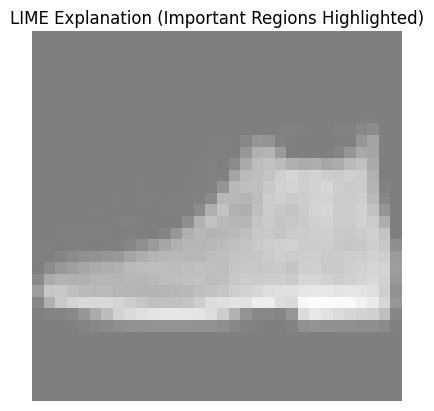

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from lime import lime_image
from skimage.segmentation import mark_boundaries

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

trainset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)

testset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"
]

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, 3)   # 1 channel (grayscale)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3)

        self.fc1 = nn.Linear(32 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # 32 → 15
        x = self.pool(torch.relu(self.conv2(x)))   # 15 → 6

        x = torch.flatten(x, 1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Training Started...\n")

for epoch in range(25):
    running_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.3f}")

print("\nTraining Completed")

def predict(images):
    images = torch.tensor(images).float()

    # Convert RGB → Grayscale (IMPORTANT FIX)
    images = images.mean(dim=3, keepdim=True)  # (N,32,32,3) → (N,32,32,1)

    images = images.permute(0, 3, 1, 2)  # → (N,1,32,32)

    outputs = model(images)
    probs = torch.softmax(outputs, dim=1)

    return probs.detach().numpy()

dataiter = iter(testloader)
images, labels = next(dataiter)

# Convert grayscale → RGB for LIME
image = images[0].numpy()[0]  # (1,32,32) → (32,32)
image_rgb = np.stack((image,)*3, axis=-1)

label = labels[0].item()

plt.imshow(image, cmap='gray')
plt.title(f"Actual Label: {classes[label]}")
plt.axis('off')
plt.show()

explainer = lime_image.LimeImageExplainer()

print("Generating LIME Explanation...")

explanation = explainer.explain_instance(
    image_rgb,
    predict,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.title("LIME Explanation (Important Regions Highlighted)")
plt.axis('off')
plt.show()